# 1. Mount Drive

In [21]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# 2. Install library tambahan

In [22]:
!pip install opencv-python-headless scikit-image mahotas -q

# 3. Import semua library

In [23]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# 4. Cek struktur folder. INI PENTING UNTUK PASTIKAN TIDAK ERROR

In [24]:
base_path = "/content/drive/MyDrive/Computer Vision 2026/UTS_ML_CV"

# Cek isi folder Training
print("Isi folder Training:")
train_path = os.path.join(base_path, "Training")
if os.path.exists(train_path):
    for folder in os.listdir(train_path):
        sub_path = os.path.join(train_path, folder)
        if os.path.isdir(sub_path):
            jumlah = len([f for f in os.listdir(sub_path) if f.endswith(('.jpg','.png','.jpeg'))])
            print(f"  - {folder}: {jumlah} gambar")
else:
    print("Folder Training tidak ditemukan! Periksa path.")

Isi folder Training:
  - glioma: 1400 gambar
  - meningioma: 1400 gambar
  - notumor: 1400 gambar
  - pituitary: 1414 gambar


# 5. Fungsi ekstraksi fitur GLCM

In [25]:
def ekstrak_ciri_glcm(gambar_path):
    img = cv2.imread(gambar_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (128, 128))
    glcm = graycomatrix(img, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast').mean()
    dissimilarity = graycoprops(glcm, 'dissimilarity').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()
    energy = graycoprops(glcm, 'energy').mean()
    correlation = graycoprops(glcm, 'correlation').mean()
    return [contrast, dissimilarity, homogeneity, energy, correlation]

# 6. Proses SEMUA gambar di Training dan Testing. (Cell ini akan berjalan agak lama. Jangan diinterupsi).

In [27]:
base_path = "/content/drive/MyDrive/Computer Vision 2026/UTS_ML_CV"
folders = ['Training', 'Testing']
kelas = ['glioma', 'meningioma', 'notumor', 'pituitary']

semua_ciri = []
semua_label = []

for folder in folders:
    for kelas_sekarang in kelas:
        path_kelas = os.path.join(base_path, folder, kelas_sekarang)
        if not os.path.exists(path_kelas):
            print(f"WARNING: {path_kelas} tidak ditemukan, lewati.")
            continue
        print(f"Memproses: {folder}/{kelas_sekarang}")
        for file in os.listdir(path_kelas):
            if file.lower().endswith(('.png','.jpg','.jpeg')):
                path_gambar = os.path.join(path_kelas, file)
                ciri = ekstrak_ciri_glcm(path_gambar)
                if ciri is not None:
                    semua_ciri.append(ciri)
                    semua_label.append(kelas_sekarang)
        print(f"  Selesai {folder}/{kelas_sekarang}")

print(f"\n✅ TOTAL GAMBAR YANG BERHASIL DIEKSTRAK: {len(semua_ciri)}")

Memproses: Training/glioma
  Selesai Training/glioma
Memproses: Training/meningioma
  Selesai Training/meningioma
Memproses: Training/notumor
  Selesai Training/notumor
Memproses: Training/pituitary
  Selesai Training/pituitary
Memproses: Testing/glioma
  Selesai Testing/glioma
Memproses: Testing/meningioma
  Selesai Testing/meningioma
Memproses: Testing/notumor
  Selesai Testing/notumor
Memproses: Testing/pituitary
  Selesai Testing/pituitary

✅ TOTAL GAMBAR YANG BERHASIL DIEKSTRAK: 7226


# 7. Simpan hasil ekstraksi ke CSV

In [28]:
columns = ['Contrast', 'Dissimilarity', 'Homogeneity', 'Energy', 'Correlation']
df = pd.DataFrame(semua_ciri, columns=columns)
df['Label'] = semua_label

# Simpan ke Drive
csv_path = "/content/drive/MyDrive/Computer Vision 2026/UTS_ML_CV/hasil_ekstraksi.csv"
df.to_csv(csv_path, index=False)
print(f"CSV tersimpan di: {csv_path}")
print("\n5 baris pertama:")
print(df.head())
print("\nJumlah data per kelas:")
print(df['Label'].value_counts())

CSV tersimpan di: /content/drive/MyDrive/Computer Vision 2026/UTS_ML_CV/hasil_ekstraksi.csv

5 baris pertama:
     Contrast  Dissimilarity  Homogeneity    Energy  Correlation   Label
0  253.970514       6.405293     0.571770  0.328891     0.928858  glioma
1  345.213410       9.151019     0.387812  0.137275     0.908537  glioma
2  244.268524       5.776138     0.588827  0.335110     0.854592  glioma
3  529.004588      11.309715     0.316558  0.087380     0.848029  glioma
4  254.289497       6.864144     0.491956  0.231674     0.891724  glioma

Jumlah data per kelas:
Label
pituitary     1826
glioma        1800
meningioma    1800
notumor       1800
Name: count, dtype: int64


# 8. Siapkan data untuk SVM

In [29]:
X = df.drop('Label', axis=1)
y = df['Label']

# Normalisasi (wajib untuk SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data latih 80% dan uji 20% (walaupun sudah ada folder Testing, kita tetap split untuk evaluasi)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data latih: {X_train.shape[0]} gambar")
print(f"Data uji: {X_test.shape[0]} gambar")

Data latih: 5780 gambar
Data uji: 1446 gambar


# 9. Latih model SVM

In [30]:
model_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model_svm.fit(X_train, y_train)

y_pred = model_svm.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)
print(f"\n🎯 AKURASI MODEL SVM: {akurasi*100:.2f}%")


🎯 AKURASI MODEL SVM: 72.27%


# 10. Hyperparameter Tuning dengan GridSearchCV

In [31]:
from sklearn.model_selection import GridSearchCV

# Definisikan parameter yang akan diuji
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

# Grid search dengan cross-validation 5 fold
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Parameter terbaik: {grid.best_params_}")
print(f"Akurasi CV terbaik: {grid.best_score_*100:.2f}%")

# Gunakan model terbaik
model_best = grid.best_estimator_
y_pred_best = model_best.predict(X_test)
akurasi_best = accuracy_score(y_test, y_pred_best)
print(f"Akurasi testing dengan model terbaik: {akurasi_best*100:.2f}%")

Parameter terbaik: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
Akurasi CV terbaik: 83.08%
Akurasi testing dengan model terbaik: 81.95%


# 10. Evaluasi lengkap

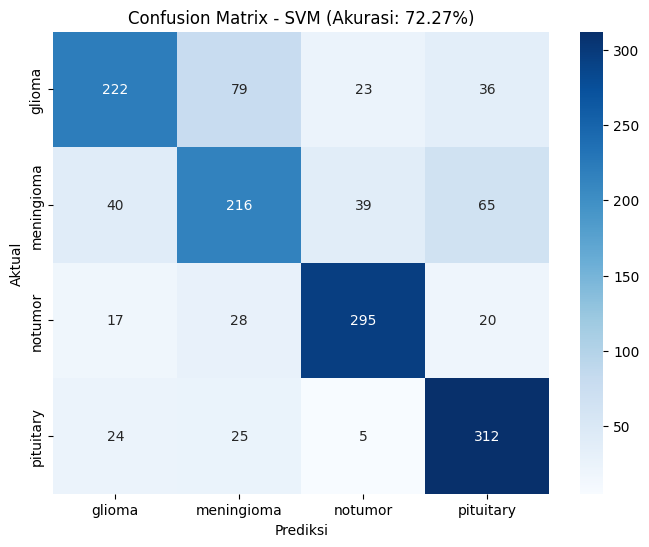


📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      glioma       0.73      0.62      0.67       360
  meningioma       0.62      0.60      0.61       360
     notumor       0.81      0.82      0.82       360
   pituitary       0.72      0.85      0.78       366

    accuracy                           0.72      1446
   macro avg       0.72      0.72      0.72      1446
weighted avg       0.72      0.72      0.72      1446



In [32]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model_svm.classes_,
            yticklabels=model_svm.classes_)
plt.title(f'Confusion Matrix - SVM (Akurasi: {akurasi*100:.2f}%)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# Classification Report
print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

# 11. Simpan model yang sudah dilatih

In [33]:
import joblib
model_path = "/content/drive/MyDrive/Computer Vision 2026/UTS_ML_CV/model_svm.pkl"
joblib.dump(model_svm, model_path)
print(f"Model tersimpan di: {model_path}")

Model tersimpan di: /content/drive/MyDrive/Computer Vision 2026/UTS_ML_CV/model_svm.pkl


# 12. Uji coba prediksi satu gambar dari folder Testing

In [34]:
def prediksi_satu_gambar(path_gambar):
    ciri = ekstrak_ciri_glcm(path_gambar)
    if ciri is None:
        print("Gambar tidak terbaca")
        return
    ciri_scaled = scaler.transform([ciri])
    pred = model_svm.predict(ciri_scaled)[0]
    print(f"Gambar: {path_gambar.split('/')[-1]}")
    print(f"Hasil prediksi: {pred}")
    return pred

# Contoh: ambil gambar pertama dari folder Testing/glioma
test_glioma_path = "/content/drive/MyDrive/Computer Vision 2026/UTS_ML_CV/Testing/glioma"
contoh_file = [f for f in os.listdir(test_glioma_path) if f.endswith(('.jpg','.png'))][0]
prediksi_satu_gambar(os.path.join(test_glioma_path, contoh_file))

Gambar: Te-gl_103.jpg
Hasil prediksi: pituitary


'pituitary'